# Quick-start
* In this tutorial we will show 
    - How to initialise the emulator.
    - How to obtain multipoles for the standard $\Lambda CDM$ cosmology.

Let’s first import `comet` as well as other requried libraries:

In [1]:
from comet import comet
import numpy as np
import matplotlib.pyplot as plt


 As it is the first instance of the emulator, we need to download some data, it can take a few seconds...


Download finished. Extracting files.
Done.


Download finished. Extracting files.
Done.



At initialisation we only need to specify the perturbation theory model that we want to use (for an overview of the models implemented in COMET, see here) and we can configure COMET either in $Mpc$ units (`use_Mpc = True`, which is the default option) or in $h^{-1}Mpc$ units (`use_Mpc = False`). All quantities that are not dimensionless are then returned or assumed to be given in the respective unit system. Let’s define an emulator object for the EFT model using the standard $h^{-1}Mpc$ units:

In [2]:
EFT=comet(model="EFT", use_Mpc=False)

In order to make predictions for a given cosmological model we first need to specify the fiducial background cosmology, from which the Alcock-Paczynski distortions will be computed. This is done by calling the function `define_fiducial_cosmology` with a dictionary specifying the cosmological parameters and the redshift:

In [3]:
params_fid = {'h':0.695, 'wc':0.11544, 'wb':0.0222191, 'z':0.57}

# This assumes by default a "lambda" cosmology with w0 = -1, for other
# options, see the in-depth examples below.
EFT.define_fiducial_cosmology(params_fid=params_fid)

The function `Pell`, which returns the power spectrum multipoles takes generally three parameters:

1. The scales for which to compute the multipoles (in the corresponding units)
2. A parameter dictionary, specifying cosmological, bias, and (if applicable) additional redshift-space distortions parameters
3. The multipole number, i.e. ell = 0, 2, 4, or a list of multipole numbers

The parameter dictionary must include all shape parameters: the physical cold dark matter and baryon densities (`wc` and `wb`) and the scalar spectral index (`ns`). In case of a flat $\Lambda CDM$ model we also need to specify values for $h$ (`h`), the amplitude of scalar fluctuations (`As`) and redshift (`z`). For other cosmologies, see In-depth options for obtaining multipoles.

In [4]:
# Let's create a parameter dictionary
params = {}

# We always need to specify the shape parameter values, e.g.
params['wc'] = 0.11544
params['wb'] = 0.0222191
params['ns'] = 0.9632

# For a LCDM cosmology, we also need:
params['h']  = 0.8
params['As'] = 2.3
params['z']  = 0.6

Finally, we define the values of the bias parameters. The complete list of parameters along with a brief explanation and their dioctionary keywords can be found here. In the following we only specify values for the linear and quadratic bias, all other parameters are automatically set to zero:

In [5]:
params['b1'] = 2.
params['b2'] = -0.5

Now, let’s compute the monopole (`ell=0`), quadrupole (`ell=2`) and hexadecapole (`ell=4`) for a range of scales from $0.001 hMpc^{−1}$ to $0.3hMpc^{−1}$:

In [6]:
k_hMpc = np.logspace(-3,np.log10(0.3),100)
Pell_LCDM = EFT.Pell(k_hMpc, params, ell=[0,2,4], de_model='lambda')

The output of `Pell` is given in a dictionary format:

In [7]:
print(Pell_LCDM.keys())

dict_keys(['ell0', 'ell2', 'ell4'])


So we can access our results and plot them as follow.

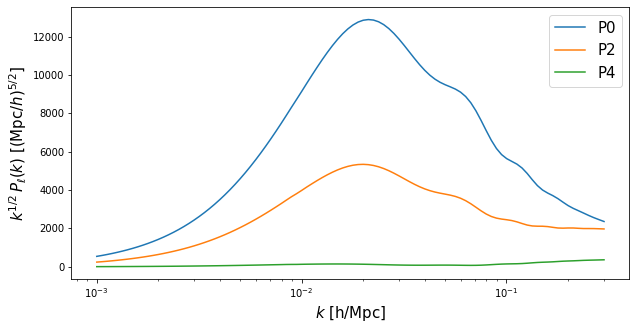

In [8]:
f = plt.figure(figsize=(10,5))
ax = f.add_subplot(111)

ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell0"],c='C0',ls='-',label='P0')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell2"],c='C1',ls='-',label='P2')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell4"],c='C2',ls='-',label='P4')
ax.set_xlabel('$k$ [h/Mpc]',fontsize=15)
ax.set_ylabel(r'$k^{1/2}\,P_{\ell}(k)$ [$(\mathrm{Mpc}/h)^{5/2}$]',fontsize=15)
ax.legend(fontsize=15)
plt.show()

# In-depth options for obtaining multipoles

* Now, let's see somo details:
    * different cosmologies ($\omega_0 + \omega_0\omega_a$)
    * using the $f-\sigma_{12}$ parameter space
    * the options for providing different $k$-scales, float vs np.array vs list and the corresponding outputs
    * describe the `fixed_cosmo_boost` function, i.e., speedup when just changing bias parameters

## An alternative Dark energy model.

As mentioned before, we can make use of a different cosmological model. Let's try the `w0wa` model. We need to add such parameters to our params dictionary first.

In [9]:
# a non-flat
# cosmology is assumed if `params_fid` includes the key `Ok`.
# For other dark energy models one can set `de_model` to `w0` or `w0wa`, in
# which case one needs to provide the values for w0, wa in `params_fid`.
params['w0'] = -1.1
params['wa'] = 0.1

Then let's recompute the model updating such parameters and compare with the $\Lambda CDM$ prediction

In [12]:
Pell_w0wa = EFT.Pell(k_hMpc, params, ell=[0,2,4], de_model='w0wa')

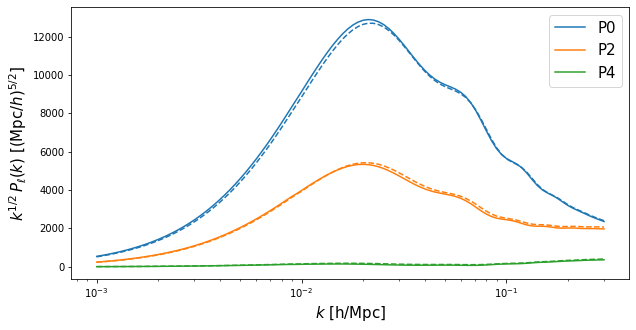

In [13]:
f = plt.figure(figsize=(10,5))
ax = f.add_subplot(111)

ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell0"],c='C0',ls='-',label='P0')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell2"],c='C1',ls='-',label='P2')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell4"],c='C2',ls='-',label='P4')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_w0wa["ell0"],c='C0',ls='--')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_w0wa["ell2"],c='C1',ls='--')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_w0wa["ell4"],c='C2',ls='--')
ax.set_xlabel('$k$ [h/Mpc]',fontsize=15)
ax.set_ylabel(r'$k^{1/2}\,P_{\ell}(k)$ [$(\mathrm{Mpc}/h)^{5/2}$]',fontsize=15)
ax.legend(fontsize=15)
plt.show()

## The $f-\sigma_{12}$ parameter space.

The function called before ignores the values of `s12`, `alpha_tr`, `alpha_lo` and `f` in the parameter dictionary and instead converts the $\Lambda$CDM parameters to the $\sigma_{12}$ parameter space. The internal values of those parameters (which can be accessed via `EFT.params`) have therefore been updated:

In [14]:
# s12, alpha_tr, alpha_lo and f are computed internally!
EFT.params

{'wc': 0.11544,
 'wb': 0.0222191,
 'ns': 0.9632,
 's12': 0.5993592953547796,
 'f': 0.7252890877752092,
 'b1': 2.0,
 'b2': -0.5,
 'g2': 0.0,
 'g21': 0.0,
 'c0': 0.0,
 'c2': 0.0,
 'c4': 0.0,
 'cnlo': 0.0,
 'NP0': 0.0,
 'NP20': 0.0,
 'NP22': 0.0,
 'NB0': 0.0,
 'MB0': 0.0,
 'h': 0.8,
 'As': 2.3,
 'Ok': 0.0,
 'w0': -1.1,
 'wa': 0.1,
 'z': 0.6,
 'alpha_tr': 1.0960392096062852,
 'alpha_lo': 1.0718295294749038}

First, we need to redefine our parameters.

In [15]:
# For predictions using the RSD parameter space we also need to specify values for the following four parameters, e.g.
params['s12']      = 0.6
params['alpha_lo'] = 1.1
params['alpha_tr'] = 0.9
params['f']        = 0.7

_Note: When computing the multipoles using the $\sigma_{12}$ parameter space we need to specify a fiducial value for the Hubble rate. This is required to convert the native emulator output from Mpc to Mpc/h units._

In [16]:
Pell_s12 = EFT.Pell(k_hMpc, params, ell=[0,2,4])

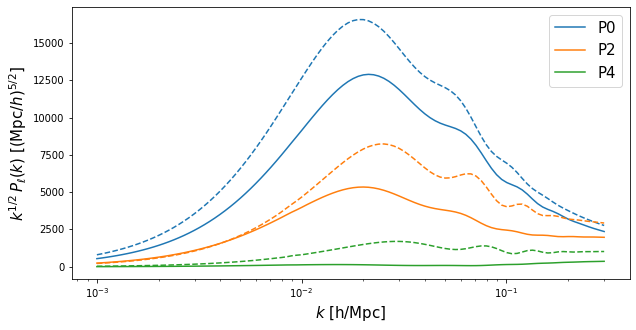

In [17]:
f = plt.figure(figsize=(10,5))
ax = f.add_subplot(111)

ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell0"],c='C0',ls='-',label='P0')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell2"],c='C1',ls='-',label='P2')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_LCDM["ell4"],c='C2',ls='-',label='P4')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_s12["ell0"],c='C0',ls='--')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_s12["ell2"],c='C1',ls='--')
ax.semilogx(k_hMpc, k_hMpc**0.5*Pell_s12["ell4"],c='C2',ls='--')
ax.set_xlabel('$k$ [h/Mpc]',fontsize=15)
ax.set_ylabel(r'$k^{1/2}\,P_{\ell}(k)$ [$(\mathrm{Mpc}/h)^{5/2}$]',fontsize=15)
ax.legend(fontsize=15)
plt.show()

## How to provide different k-scales.

The scales for which to compute the multipoles: if given as a number or numpy array all specified multipoles will be computed for those scales, if given as a list, the length must match the number of specified multipoles (`ell`) and the first entry of the list is evaluated for the first multipole etc.

We can output at a single scale and single multipole number, e.g. for the quadrupole at $k = 0.1 1/Mpc$:

In [18]:
# The provided scales are also assumed to be in 1/Mpc units
EFT.Pell(0.1, params, ell=2)

{'ell2': array([12734.58398179])}

Or for various multipoles and multiple scales, in which case the output is a list with the first entry corresponding to the first multipole specified in `ell`:

In [19]:
EFT.Pell(np.array([0.1,0.2,0.3]), params, ell=[0,2,4])

{'ell0': array([21993.36207412,  8421.42619583,  5055.15983889]),
 'ell2': array([12734.58398179,  7163.04233122,  5357.26630447]),
 'ell4': array([3027.98289548, 2244.35666682, 1870.99370539])}

Or at different scales for different multipoles (providing a list of numbers or numpy arrays):

In [20]:
EFT.Pell([np.array([0.1,0.2]),0.3], params, ell=[0,4])

{'ell0': array([21993.36207412,  8421.42619583]),
 'ell4': array([1870.99370539])}

## Speedup when changing just bias parameters.

It is a common task to test the models just by changing parameters that does not involve any cosmological computation. On that case we can call the function `Pell_fixed_cosmo_boost`, which looks into the parameters specified and if any cosmological parameter has changed, it uses the computation from previous calls. In the following cells the diferences on time can be seen, which reflects a speed up of around 3 orders of magnitude.

In [21]:
%timeit EFT.Pell(k_hMpc, params, ell=[0,2,4], de_model="lambda")

15.6 ms ± 771 µs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [22]:
%timeit EFT.Pell_fixed_cosmo_boost(k_hMpc, params, ell=[0,2,4], de_model="lambda")

23.2 µs ± 1.38 µs per loop (mean ± std. dev. of 7 runs, 10000 loops each)


# Beyond $P_{\ell}$ predictions.

We have included some required tools needed for cosmological analysis in order to make easiert to integrate it into a complete pipeline

## Computing covariance matrices

Apart from the multipoles we can also generate (Gaussian) covariance matrices, for which there are again different flags, that are either defined for the $\sigma_{12}$ or the $\Lambda$CDM parameter spaces. The first three arguments, `k`, `params`, and `ell`, are identical to those for `Pell`. In addition, we need to specify a binwidth `dk` and volume (both of which need to be given in the respective units for which the emulator is configured in), for example:

In [23]:
dk_hMpc = 0.001
k_hMpc_lin = np.arange(0.001, 0.3, dk_hMpc)

In [24]:
Cov_hMpc = EFT.Pell_covariance(k_hMpc, params, ell=[0,2,4], dk=dk_hMpc, volume=3e9)

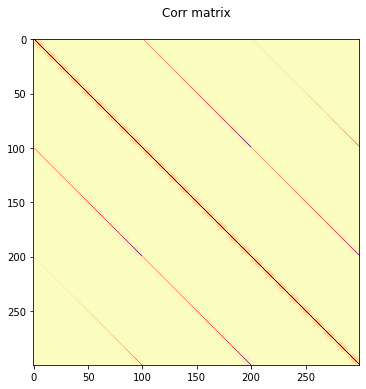

In [25]:
plt.figure(figsize=(9,6))
plt.title(r"")
plt.title(r"Corr matrix", y=1.05)
var_inv = np.diag(1./np.sqrt(np.diag(Cov_hMpc)))
R_hMpc = var_inv @ Cov_hMpc @ var_inv
plt.imshow(R_hMpc,cmap='magma_r', interpolation="blackman", filterrad=10)
plt.show()

For the $\Lambda$CDM version, instead of providing a volume, we can provide minimum and maximum redshifts, `zmin` and `zmax`, a sky fraction `fsky`, and a volume scaling factor `volfac` (by default equal to 1), which computes then evalutes the corresponding volume, also assuming a flat $\Lambda$CDM model. For example:

In [26]:
Cov_hMpc_LCDM = EFT.Pell_covariance(
                        k_hMpc, 
                        params, 
                        ell=[0,2,4],
                        dk=2*np.pi/3780, 
                        zmin=params['z']-0.1, 
                        zmax=params['z']+0.1, 
                        fsky=15000./(360**2/np.pi), 
                        volfac=1, 
                        de_model="lambda", 
                        volume=3780**3
                )

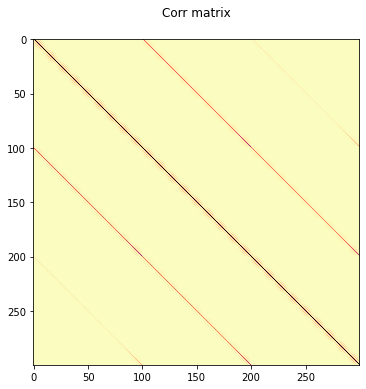

In [27]:
plt.figure(figsize=(9,6))
plt.title(r"")
plt.title(r"Corr matrix", y=1.05)
var_inv = np.diag(1./np.sqrt(np.diag(Cov_hMpc_LCDM)))
R_hMpc = var_inv @ Cov_hMpc_LCDM @ var_inv
plt.imshow(R_hMpc,cmap='magma_r', interpolation="blackman", filterrad=10)
plt.show()

As a further extension, in the case when using measurements on a cubic box along diferent line of sight an averaging them, we have added the averaging corrections for the covariance. We have created the flags `avg_cov=False`, `avg_los=3` for the `Pell_covariance` function, so that when you set the `avg_cov=True` it by default will make the average along 3 axis, but we have included the option to correct for averaging on only 2 directions. Note that this computation is quite slow since it involves a different  integral for each k-bin, maybe in the future it can be optimised.

## Computing the $\chi^2$

Finally, the Comet class provides a function to directly compute the $\chi^2$. In order to do so, we need to specify the data set, i.e., range of scales of the observations, the measured multipoles and their covariance matrix. As before, these must be given in the same unit system as that for which the emulator has been configured.

In [28]:
# Loading a sample data set:
data = np.loadtxt('../../../../data/cmass/Minerva_HOD_zs_z0.57_pkmulti_mean.dat')
cov = np.loadtxt('../../../../data/cmass/Minerva_HOD_zs_z0.57_pkmulti_covar.dat')

As the data vector would have an assosiated shot noise, we can specify it by indicating the number density of the sample.

In [29]:
EFT.define_nbar(nbar=3.95898e-4)

We have the option of specifying whether the covariance matrix is a "theory" covariance matrix or not. If `theory_cov = False`, the Anderson-Hartlap factor is included in the inverse covariance matrix, which is why we need to also provide the number of n_realizations from which the covariance matrix was estimated (if `theory_cov = True`, `Nrealizations` can be ignored).

In [30]:
EFT.define_data_set(obs_id='Pk', bins=data[:,0], signal=data[:,(1,3,5)], cov=cov, theory_cov=False, n_realizations=300)

Now we can call `chi2`, which takes as arguments the parameter dictionary, a maximum k-mode value `kmax`, a model argument `de_model`. `kmax` can either be a number, in which case the same cutoff is applied for all multipoles, or a list of numbers for each individual multipole, as for the multipoles case. If the cutoff is zero (or smaller than the minimum scale of the observations) for a particular multipole, then it is excluded from the computation of the chi-square. `kmax` is also assumed to be in the units of the emulator. `de_model` can be one of the specified before. 

In [31]:
EFT.chi2(obs_id='Pk',params=params, kmax=[0.3,0.30, 0.30], de_model='lambda', chi2_decomposition=False)

9464.265846193817

Moreover, in order to speed up the computation of the $\chi^2$, in the same way as `Pell_fixed_cosmo_boost` function, we can specify the flag `chi2_decomposition` in order to avoid recompute the cosmological dependent quantities. Let's see how it works

In [32]:
%timeit EFT.chi2(obs_id='Pk',params=params, kmax=[0.3,0.30, 0.30], de_model='lambda', chi2_decomposition=False)

17.2 ms ± 1.62 ms per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [33]:
%timeit EFT.chi2(obs_id='Pk',params=params, kmax=[0.3,0.30, 0.30], de_model='lambda', chi2_decomposition=True)

30.3 µs ± 7.94 µs per loop (mean ± std. dev. of 7 runs, 1 loop each)


## Further features of the package

### the prediction of the linear matter power spectrum, with or without application of infrared resummation (BAO damping)

In [34]:
PLO = EFT.Pdw(params=params, k=k_hMpc, de_model='lambda',)
PL = EFT.PL(params=params, k=k_hMpc, de_model='lambda',)

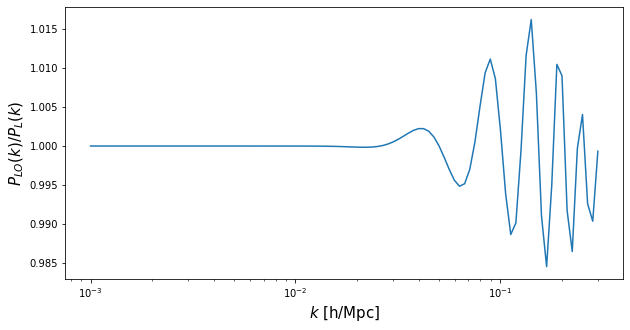

In [35]:
f = plt.figure(figsize=(10,5))
ax = f.add_subplot(111)

ax.semilogx(k_hMpc, PLO/PL,c='C0',ls='-')
ax.set_xlabel('$k$ [h/Mpc]',fontsize=15)
ax.set_ylabel(r'$P_{LO}(k)/P_{L}(k)$',fontsize=15)
plt.show()

### the prediction of the real-space tree-level galaxy bispectrum and the tree-level galaxy bispectrum multipoles in redshift-space

In [36]:
tri =[]
for k1 in k_hMpc:
    for k2 in k_hMpc:
        for k3 in k_hMpc:
            if k1 >= k2 >=k3:
                tri.append([k1, k2, k3])
tri=np.asarray(tri)

In [37]:
Bell = EFT.Bell(tri, params=params, ell=[0,2,4], de_model='lambda')

kfun not specified. Using kfun = 0.001


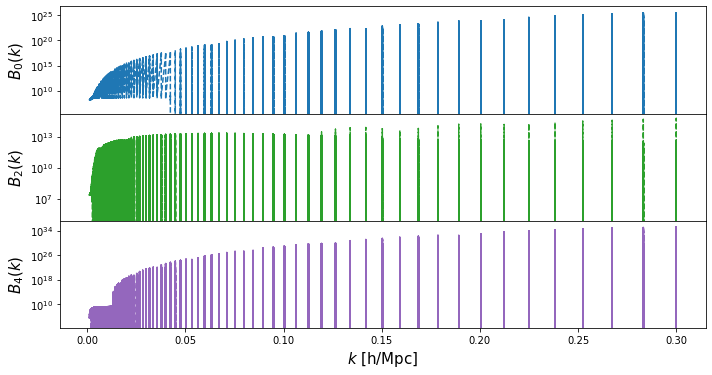

In [38]:
fig, axs = plt.subplots(3,1, figsize=(10,5), sharex=True,)

for i in range(3):
    axs[i].semilogy(np.asarray(tri).T[0], Bell["ell"+str(2*i)],c='C'+str(2*i),ls='--')
    axs[i].set_ylabel(f'$B_{i*2}(k)$',fontsize=15)

fig.tight_layout()
plt.subplots_adjust(wspace=0, hspace=0)
axs[-1].set_xlabel('$k$ [h/Mpc]',fontsize=15)
plt.show()